## Step 1: Generate Data Set

In [2]:
import pandas as pd
import numpy as np

n = 50000
data = {
    "Patient_ID": np.arange(1, n+1),
    "Age": np.random.randint(18, 90, n),
    "Gender": np.random.choice(["Male", "Female"], n),
    "BMI": np.round(np.random.uniform(15, 45, n), 1),
    "Glucose": np.round(np.random.uniform(70, 200, n), 1),
    "Smoking": np.random.choice([0, 1], n, p=[0.7, 0.3]),
    "Alcohol": np.random.choice([0, 1], n, p=[0.6, 0.4]),
    "Exercise": np.random.choice([0, 1], n, p=[0.5, 0.5]),
}

df = pd.DataFrame(data)

# Simple rule-based risk assignment
df["Risk_Category"] = ((df["BMI"] > 30) | (df["Glucose"] > 140)).astype(int)

df.to_csv("synthetic_patient_data.csv", index=False)


In [4]:
print(df.head())

   Patient_ID  Age  Gender   BMI  Glucose  Smoking  Alcohol  Exercise  \
0           1   77  Female  23.2     78.7        0        1         1   
1           2   80  Female  16.1    180.1        1        1         0   
2           3   68  Female  21.6    109.3        0        1         0   
3           4   74    Male  35.6    140.1        0        1         0   
4           5   35  Female  25.4     82.2        1        0         0   

   Risk_Category  
0              0  
1              1  
2              0  
3              1  
4              0  


## Step 2: Exploratory data analysis (EDA) and handling of missing values

### Check for missing values

In [5]:
print('Missing values per column:')
display(df.isnull().sum())

Missing values per column:


,0
Patient_ID,0
Age,0
Gender,0
BMI,0
Glucose,0
Smoking,0
Alcohol,0
Exercise,0
Risk_Category,0


### Data Imputation Strategy

During the initial check, it was confirmed that there are **no missing values** in the dataset (`df.isnull().sum()` showed all zeros). Therefore, no imputation strategy is required for this dataset.

However, if missing values were present, a common strategy would involve:

*   **Numerical Features:** Imputing with the mean, median, or mode, depending on the distribution of the data. For normally distributed data, the mean is often used, while for skewed data, the median is preferred. Alternatively, more sophisticated methods like K-Nearest Neighbors (KNN) imputation or regression imputation could be employed.
*   **Categorical Features:** Imputing with the mode (most frequent category) or creating a new category for 'Missing'.

The choice of imputation method heavily depends on the nature of the missingness (e.g., Missing At Random, Missing Completely At Random) and the downstream modeling tasks.

### Display data types and general information

In [6]:
print('DataFrame Info:')
df.info()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Patient_ID     50000 non-null  int64  
 1   Age            50000 non-null  int64  
 2   Gender         50000 non-null  object 
 3   BMI            50000 non-null  float64
 4   Glucose        50000 non-null  float64
 5   Smoking        50000 non-null  int64  
 6   Alcohol        50000 non-null  int64  
 7   Exercise       50000 non-null  int64  
 8   Risk_Category  50000 non-null  int64  
dtypes: float64(2), int64(6), object(1)
memory usage: 3.4+ MB


### Descriptive statistics for numerical features

In [7]:
print('Descriptive statistics:')
display(df.describe())

Descriptive statistics:


,Patient_ID,Age,BMI,Glucose,Smoking,Alcohol,Exercise,Risk_Category
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,53.510100,29.939306,135.188274,0.295820,0.402280,0.500460,0.728840
std,14433.901067,20.811394,8.671698,37.552391,0.456415,0.490363,0.500005,0.444563
min,1.000000,18.000000,15.000000,70.000000,0.000000,0.000000,0.000000,0.000000
25%,12500.750000,35.000000,22.400000,102.500000,0.000000,0.000000,0.000000,0.000000
50%,25000.500000,53.000000,29.900000,135.500000,0.000000,0.000000,1.000000,1.000000
75%,37500.250000,72.000000,37.500000,167.800000,1.000000,1.000000,1.000000,1.000000
max,50000.000000,89.000000,45.000000,200.000000,1.000000,1.000000,1.000000,1.000000


### Explicit Calculation of Mean, Median, and Variance for Numerical Features

In [17]:
numerical_cols = ['Age', 'BMI', 'Glucose']

for col in numerical_cols:
    print(f'\n--- {col} ---')
    print(f'Mean: {df[col].mean():.2f}')
    print(f'Median: {df[col].median():.2f}')
    print(f'Variance: {df[col].var():.2f}')


--- Age ---
Mean: 53.51
Median: 53.00
Variance: 433.11

--- BMI ---
Mean: 29.94
Median: 29.90
Variance: 75.20

--- Glucose ---
Mean: 135.19
Median: 135.50
Variance: 1410.18


### Feature Correlation Heatmap

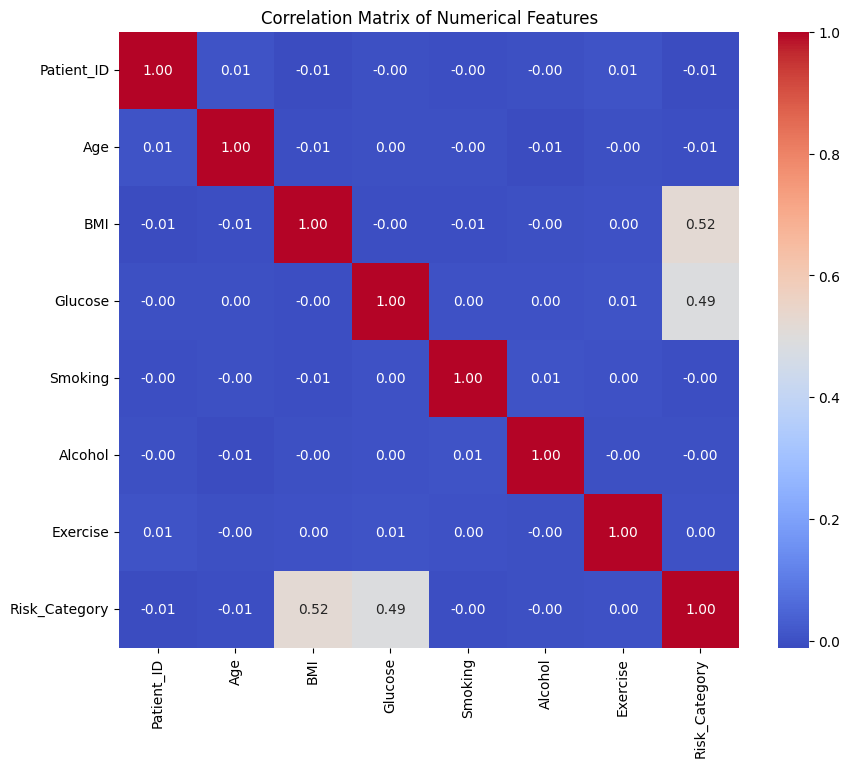

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for correlation calculation
numerical_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10, 8))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Descriptive statistics for categorical features

## Step 3: Data Visualization

### Visualize Distributions of Numerical Features

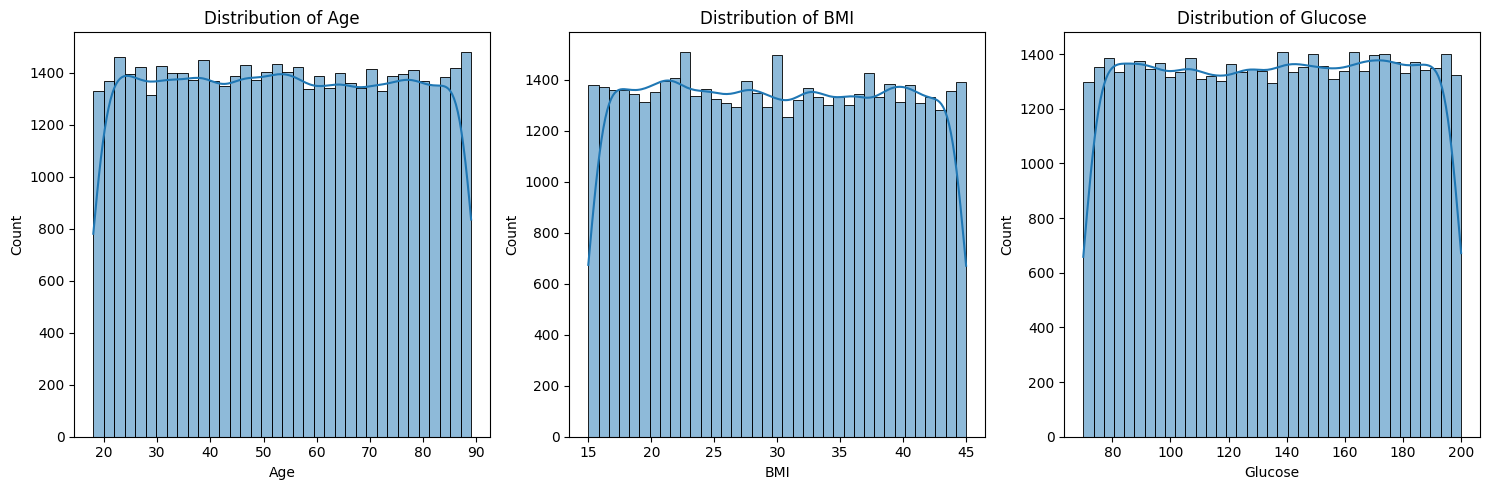

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(df['Age'], kde=True)
plt.title('Distribution of Age')

plt.subplot(1, 3, 2)
sns.histplot(df['BMI'], kde=True)
plt.title('Distribution of BMI')

plt.subplot(1, 3, 3)
sns.histplot(df['Glucose'], kde=True)
plt.title('Distribution of Glucose')

plt.tight_layout()
plt.show()

### Visualize Counts of Categorical Features

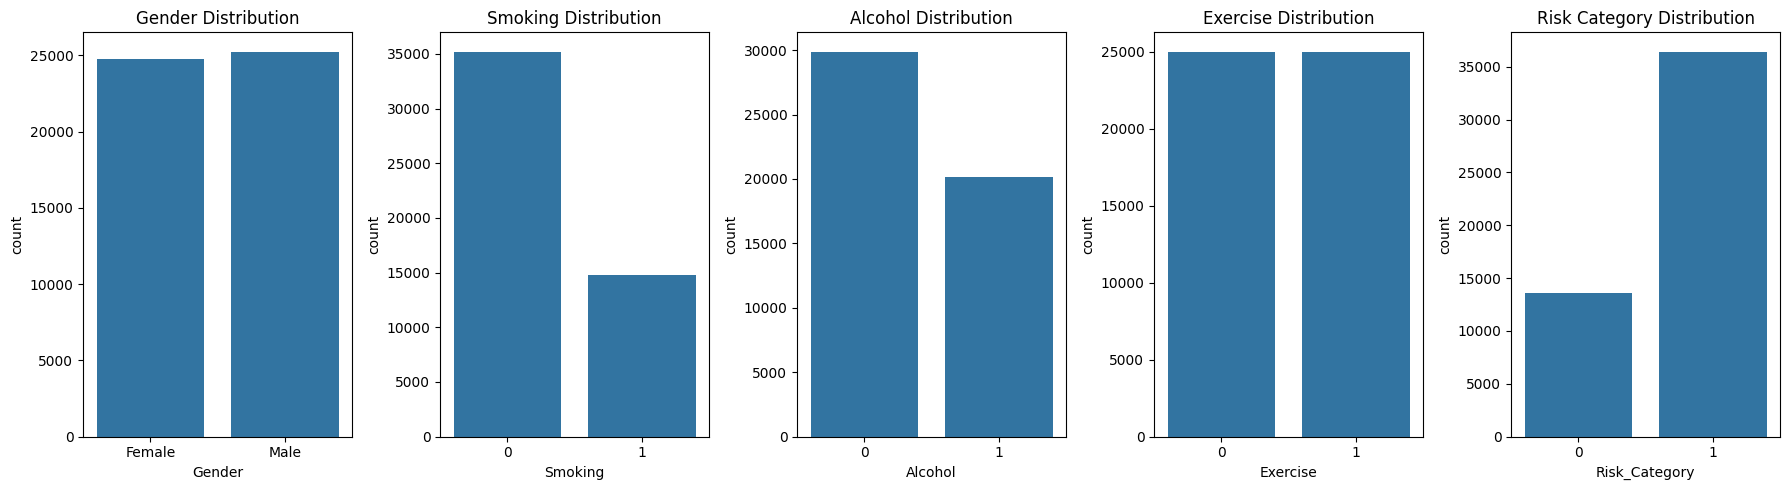

In [10]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 5, 1)
sns.countplot(x='Gender', data=df)
plt.title('Gender Distribution')

plt.subplot(1, 5, 2)
sns.countplot(x='Smoking', data=df)
plt.title('Smoking Distribution')

plt.subplot(1, 5, 3)
sns.countplot(x='Alcohol', data=df)
plt.title('Alcohol Distribution')

plt.subplot(1, 5, 4)
sns.countplot(x='Exercise', data=df)
plt.title('Exercise Distribution')

plt.subplot(1, 5, 5)
sns.countplot(x='Risk_Category', data=df)
plt.title('Risk Category Distribution')

plt.tight_layout()
plt.show()

### Explore Relationships: Risk Category vs. other features

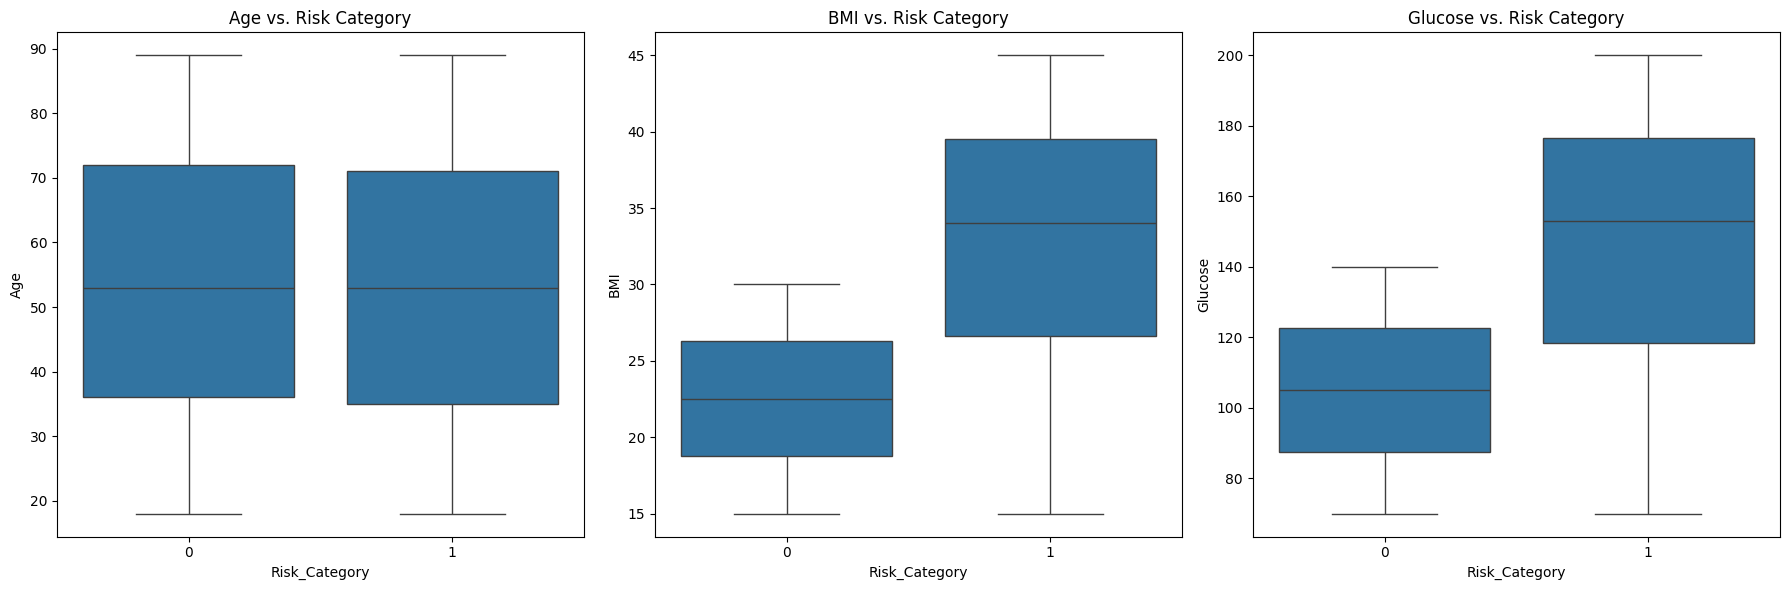

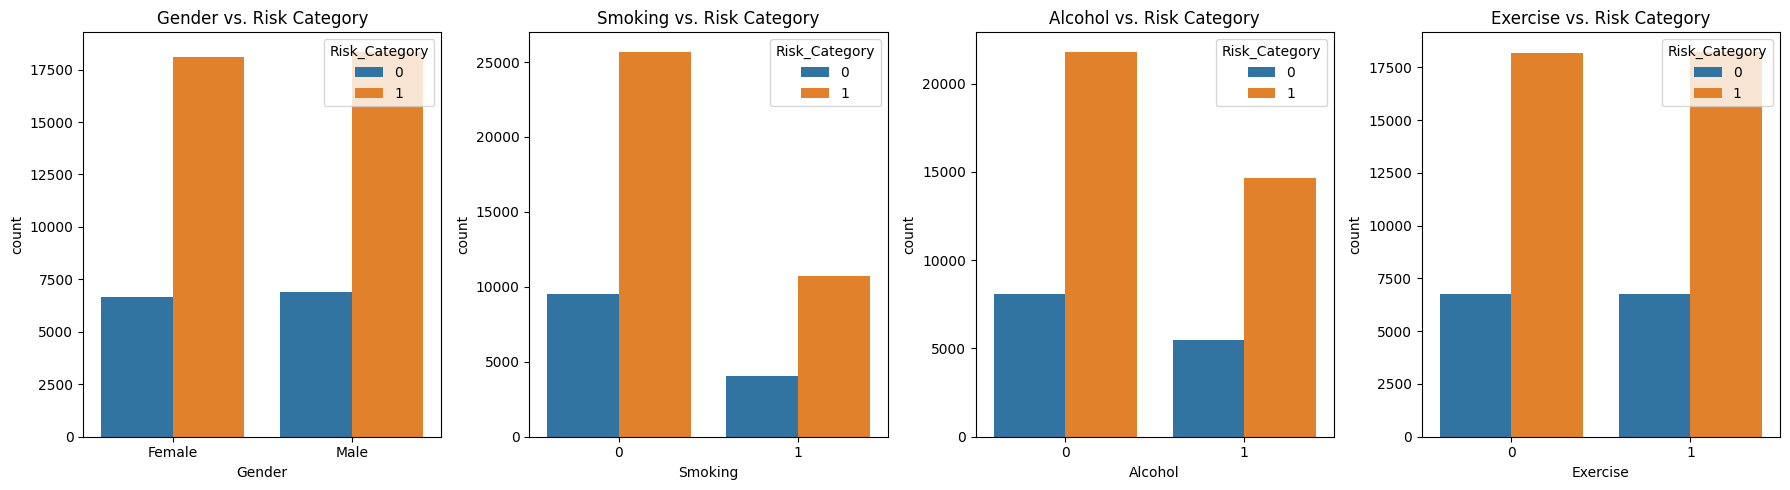

In [11]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
sns.boxplot(x='Risk_Category', y='Age', data=df)
plt.title('Age vs. Risk Category')

plt.subplot(1, 3, 2)
sns.boxplot(x='Risk_Category', y='BMI', data=df)
plt.title('BMI vs. Risk Category')

plt.subplot(1, 3, 3)
sns.boxplot(x='Risk_Category', y='Glucose', data=df)
plt.title('Glucose vs. Risk Category')

plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 5))

plt.subplot(1, 4, 1)
sns.countplot(x='Gender', hue='Risk_Category', data=df)
plt.title('Gender vs. Risk Category')

plt.subplot(1, 4, 2)
sns.countplot(x='Smoking', hue='Risk_Category', data=df)
plt.title('Smoking vs. Risk Category')

plt.subplot(1, 4, 3)
sns.countplot(x='Alcohol', hue='Risk_Category', data=df)
plt.title('Alcohol vs. Risk Category')

plt.subplot(1, 4, 4)
sns.countplot(x='Exercise', hue='Risk_Category', data=df)
plt.title('Exercise vs. Risk Category')

plt.tight_layout()
plt.show()

## Step 4: Feature Engineering and Data Preparation

### One-Hot Encoding for Categorical Features

In [12]:
# Perform one-hot encoding for 'Gender'
df_encoded = pd.get_dummies(df, columns=['Gender'], drop_first=True)

# Display the first few rows of the encoded DataFrame and its info to verify
print('DataFrame after one-hot encoding:')
display(df_encoded.head())
df_encoded.info()

DataFrame after one-hot encoding:


,Patient_ID,Age,BMI,Glucose,Smoking,Alcohol,Exercise,Risk_Category,Gender_Male
0,1,77,23.2,78.7,0,1,1,0,False
1,2,80,16.1,180.1,1,1,0,1,False
2,3,68,21.6,109.3,0,1,0,0,False
3,4,74,35.6,140.1,0,1,0,1,True
4,5,35,25.4,82.2,1,0,0,0,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Patient_ID     50000 non-null  int64  
 1   Age            50000 non-null  int64  
 2   BMI            50000 non-null  float64
 3   Glucose        50000 non-null  float64
 4   Smoking        50000 non-null  int64  
 5   Alcohol        50000 non-null  int64  
 6   Exercise       50000 non-null  int64  
 7   Risk_Category  50000 non-null  int64  
 8   Gender_Male    50000 non-null  bool   
dtypes: bool(1), float64(2), int64(6)
memory usage: 3.1 MB


### Split Data into Training and Testing Sets

### Feature Scaling

In [18]:
from sklearn.preprocessing import StandardScaler

# Identify numerical features to scale (excluding Patient_ID and binary/categorical features)
numerical_features = ['Age', 'BMI', 'Glucose']

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data's numerical features and transform both training and test sets
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

print('Numerical features scaled successfully.')

# Display the first few rows of the scaled training data to verify
print('\nX_train after scaling:')
display(X_train.head())

Numerical features scaled successfully.

X_train after scaling:


,Age,BMI,Glucose,Smoking,Alcohol,Exercise,Gender_Male
3235,-0.939023,-0.256040,-0.956726,0,0,1,False
14081,-0.602356,-0.994097,-0.706442,1,1,1,False
40262,0.984784,-1.651428,-1.547824,0,0,0,True
40009,0.696213,1.358458,-1.566462,0,1,0,True
32802,0.215262,0.654998,1.394352,0,0,0,False


In [19]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(['Patient_ID', 'Risk_Category'], axis=1)
y = df_encoded['Risk_Category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

print('\nDistribution of Risk_Category in training set:')
display(y_train.value_counts(normalize=True))

print('\nDistribution of Risk_Category in test set:')
display(y_test.value_counts(normalize=True))

X_train shape: (35000, 7)
X_test shape: (15000, 7)
y_train shape: (35000,)
y_test shape: (15000,)

Distribution of Risk_Category in training set:


,proportion
Risk_Category,
1,0.728829
0,0.271171



Distribution of Risk_Category in test set:


,proportion
Risk_Category,
1,0.728867
0,0.271133


### Train a Logistic Regression Model

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')
log_reg_model.fit(X_train, y_train)

print('Logistic Regression model trained successfully.')

Logistic Regression model trained successfully.


### Model Evaluation

In [23]:
# Make predictions on the test set
y_pred = log_reg_model.predict(X_test)

# Evaluate the model
print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('\nClassification Report:\n', classification_report(y_test, y_pred))

Accuracy: 0.9098666666666667

Confusion Matrix:
 [[ 3269   798]
 [  554 10379]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.80      0.83      4067
           1       0.93      0.95      0.94     10933

    accuracy                           0.91     15000
   macro avg       0.89      0.88      0.88     15000
weighted avg       0.91      0.91      0.91     15000



### Re-training Logistic Regression Model with Scaled Features

In [20]:
from sklearn.linear_model import LogisticRegression

# Re-initialize and train the Logistic Regression model with scaled features
log_reg_model_scaled = LogisticRegression(random_state=42, solver='liblinear')
log_reg_model_scaled.fit(X_train, y_train)

print('Logistic Regression model re-trained successfully with scaled features.')

Logistic Regression model re-trained successfully with scaled features.


### Re-evaluate Model Performance

In [21]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Make predictions on the test set using the re-trained model
y_pred_scaled = log_reg_model_scaled.predict(X_test)

# Evaluate the model
print('Accuracy (with scaled features):', accuracy_score(y_test, y_pred_scaled))
print('\nConfusion Matrix (with scaled features):\n', confusion_matrix(y_test, y_pred_scaled))
print('\nClassification Report (with scaled features):\n', classification_report(y_test, y_pred_scaled))

Accuracy (with scaled features): 0.9098666666666667

Confusion Matrix (with scaled features):
 [[ 3269   798]
 [  554 10379]]

Classification Report (with scaled features):
               precision    recall  f1-score   support

           0       0.86      0.80      0.83      4067
           1       0.93      0.95      0.94     10933

    accuracy                           0.91     15000
   macro avg       0.89      0.88      0.88     15000
weighted avg       0.91      0.91      0.91     15000



### Confusion Matrix Visualization

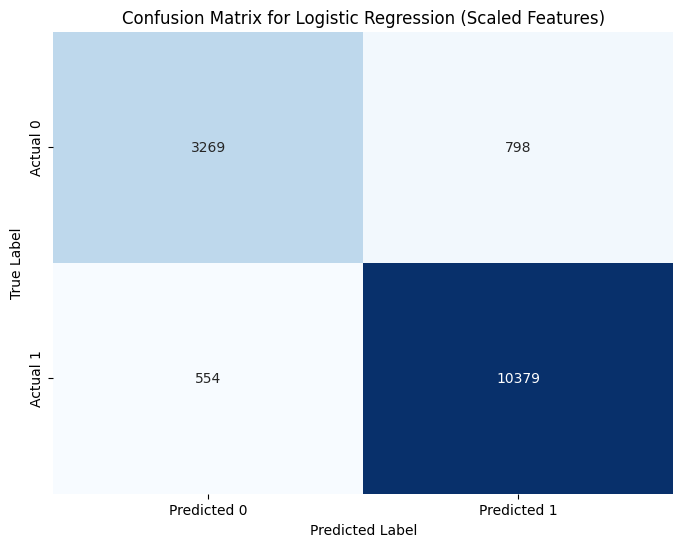

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_scaled)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for Logistic Regression (Scaled Features)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Precision-Recall Curve Analysis

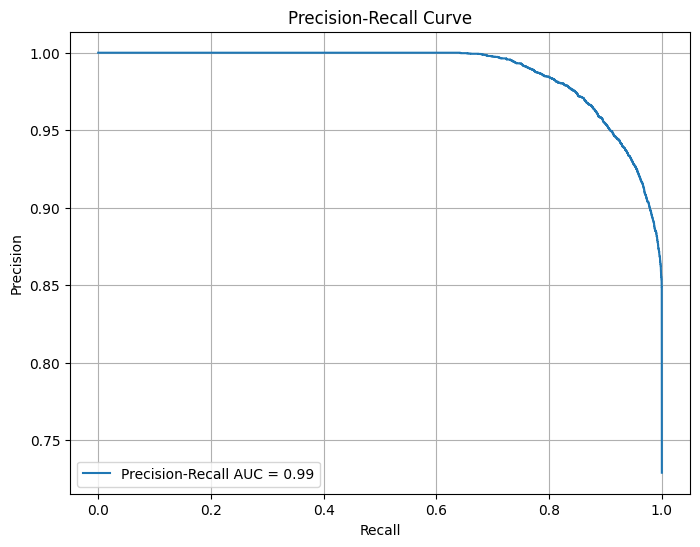

In [25]:
from sklearn.metrics import precision_recall_curve, auc

# Get probability predictions for the positive class
y_scores = log_reg_model_scaled.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Precision-Recall AUC = {pr_auc:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

### Final Model Performance Report

In [26]:
from sklearn.metrics import classification_report, accuracy_score, f1_score, recall_score

accuracy = accuracy_score(y_test, y_pred_scaled)
recall_class_1 = recall_score(y_test, y_pred_scaled, pos_label=1)
f1_score_macro = f1_score(y_test, y_pred_scaled, average='macro')

print(f'Accuracy: {accuracy:.4f}')
print(f'Recall (for Risk_Category 1): {recall_class_1:.4f}')
print(f'Macro F1-Score: {f1_score_macro:.4f}')

print('\nFull Classification Report:\n')
print(classification_report(y_test, y_pred_scaled))

Accuracy: 0.9099
Recall (for Risk_Category 1): 0.9493
Macro F1-Score: 0.8837

Full Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.80      0.83      4067
           1       0.93      0.95      0.94     10933

    accuracy                           0.91     15000
   macro avg       0.89      0.88      0.88     15000
weighted avg       0.91      0.91      0.91     15000



### Threshold Adjustment Recommendations (Target Recall >= 0.85)

In [27]:
from sklearn.metrics import recall_score

y_scores = log_reg_model_scaled.predict_proba(X_test)[:, 1]

current_recall = recall_score(y_test, y_pred_scaled, pos_label=1)
print(f"Current Recall for Risk_Category 1: {current_recall:.4f}")

target_recall = 0.85

if current_recall >= target_recall:
    print(f"The current recall ({current_recall:.4f}) already meets or exceeds the target recall of {target_recall}.")
else:
    print(f"The current recall ({current_recall:.4f}) is below the target recall of {target_recall}.")
    print("To achieve a recall of at least 0.85, we can adjust the classification threshold.")

    # Find a threshold that gives the desired recall
    precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

    # Iterate through thresholds to find one that satisfies the recall requirement
    optimal_threshold = 0.5 # Default
    for i in range(len(thresholds)):
        if recall[i] >= target_recall:
            optimal_threshold = thresholds[i]
            # Optionally, you might want the highest precision for this recall
            # For simplicity, we just take the first one that meets the recall criteria
            break

    print(f"A potential adjusted threshold to achieve recall >= {target_recall} is approximately {optimal_threshold:.4f}")

    # Apply the new threshold and re-evaluate
    y_pred_adjusted = (y_scores >= optimal_threshold).astype(int)
    adjusted_recall = recall_score(y_test, y_pred_adjusted, pos_label=1)
    adjusted_precision = precision_score(y_test, y_pred_adjusted, pos_label=1)
    adjusted_f1 = f1_score(y_test, y_pred_adjusted, pos_label=1)

    print(f"\nWith adjusted threshold of {optimal_threshold:.4f}:")
    print(f"  New Recall (for Risk_Category 1): {adjusted_recall:.4f}")
    print(f"  New Precision (for Risk_Category 1): {adjusted_precision:.4f}")
    print(f"  New F1-Score (for Risk_Category 1): {adjusted_f1:.4f}")
    print("  Note: Adjusting the threshold to increase recall often leads to a decrease in precision.")

Current Recall for Risk_Category 1: 0.9493
The current recall (0.9493) already meets or exceeds the target recall of 0.85.


## Step 6: Hyperparameter Tuning to Optimize Logistic Regression Model

In [28]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Define the parameter grid to search
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'] # 'liblinear' works well for small datasets and L1/L2 regularization, 'lbfgs' for larger datasets.
}

# Initialize Logistic Regression model
log_reg = LogisticRegression(random_state=42, max_iter=1000) # Increased max_iter for convergence

# Initialize GridSearchCV
grid_search = GridSearchCV(log_reg, param_grid, cv=5, scoring='recall', n_jobs=-1) # Using recall as scoring metric

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print('GridSearchCV completed.')
print(f'Best parameters found: {grid_search.best_params_}')
print(f'Best recall score found: {grid_search.best_score_:.4f}')

GridSearchCV completed.
Best parameters found: {'C': 0.001, 'solver': 'liblinear'}
Best recall score found: 0.9803


### Re-train Model with Best Hyperparameters and Re-evaluate

In [29]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, recall_score, f1_score

# Get the best model from GridSearchCV
best_log_reg_model = grid_search.best_estimator_

# Make predictions on the test set with the optimized model
y_pred_optimized = best_log_reg_model.predict(X_test)

# Evaluate the optimized model
print('Accuracy (optimized model):', accuracy_score(y_test, y_pred_optimized))
print('\nConfusion Matrix (optimized model):\n', confusion_matrix(y_test, y_pred_optimized))
print('\nClassification Report (optimized model):\n', classification_report(y_test, y_pred_optimized))

# Check recall for Risk_Category 1 against target
recall_optimized = recall_score(y_test, y_pred_optimized, pos_label=1)
print(f'\nRecall (for Risk_Category 1) with optimized model: {recall_optimized:.4f}')

target_recall = 0.85
if recall_optimized >= target_recall:
    print(f"The optimized model's recall ({recall_optimized:.4f}) meets or exceeds the target recall of {target_recall}.")
else:
    print(f"The optimized model's recall ({recall_optimized:.4f}) is below the target recall of {target_recall}.")

Accuracy (optimized model): 0.8084666666666667

Confusion Matrix (optimized model):
 [[ 1427  2640]
 [  233 10700]]

Classification Report (optimized model):
               precision    recall  f1-score   support

           0       0.86      0.35      0.50      4067
           1       0.80      0.98      0.88     10933

    accuracy                           0.81     15000
   macro avg       0.83      0.66      0.69     15000
weighted avg       0.82      0.81      0.78     15000


Recall (for Risk_Category 1) with optimized model: 0.9787
The optimized model's recall (0.9787) meets or exceeds the target recall of 0.85.


## Step 5: Model Selection and Training

In [8]:
print('Value counts for Gender:')
display(df['Gender'].value_counts())

print('\nValue counts for Smoking:')
display(df['Smoking'].value_counts())

print('\nValue counts for Alcohol:')
display(df['Alcohol'].value_counts())

print('\nValue counts for Exercise:')
display(df['Exercise'].value_counts())

print('\nValue counts for Risk_Category:')
display(df['Risk_Category'].value_counts())

Value counts for Gender:


,count
Gender,
Male,25253
Female,24747



Value counts for Smoking:


,count
Smoking,
0,35209
1,14791



Value counts for Alcohol:


,count
Alcohol,
0,29886
1,20114



Value counts for Exercise:


,count
Exercise,
1,25023
0,24977



Value counts for Risk_Category:


,count
Risk_Category,
1,36442
0,13558
